In [1]:
import pandas as pd
df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
df.tail(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [3]:
print("The number of rows is ",df.shape[0])
print("The number of columns is",df.shape[1])

The number of rows is  100000
The number of columns is 9


In [4]:
print("The names of columns are\n",df.columns)

The names of columns are
 Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [5]:
df["diabetes"] = df["diabetes"].replace({0: "No", 1: "Yes"})
df["heart_disease"] = df["heart_disease"].replace({0: "No", 1: "Yes"})
df["hypertension"]=df["hypertension"].replace({0:"No",1:"Yes"})
df.head(5)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,No,Yes,never,25.19,6.6,140,No
1,Female,54.0,No,No,No Info,27.32,6.6,80,No
2,Male,28.0,No,No,never,27.32,5.7,158,No
3,Female,36.0,No,No,current,23.45,5.0,155,No
4,Male,76.0,Yes,Yes,current,20.14,4.8,155,No


In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
num_cols.describe()

,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,27.320767,5.527507,138.058060
std,22.516840,6.636783,1.070672,40.708136
min,0.080000,10.010000,3.500000,80.000000
25%,24.000000,23.630000,4.800000,100.000000
50%,43.000000,27.320000,5.800000,140.000000
75%,60.000000,29.580000,6.200000,159.000000
max,80.000000,95.690000,9.000000,300.000000


In [7]:
df.dtypes

gender                  object
age                    float64
hypertension            object
heart_disease           object
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                object
dtype: object

In [8]:
df.isnull()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False


In [9]:
for col in num_cols:
    df.loc[:,col]=df[col].fillna(df[col].mean())

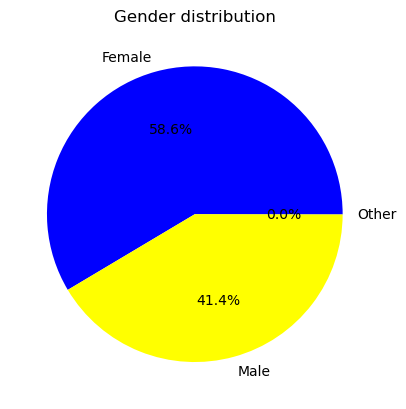

In [10]:
import matplotlib.pyplot as plt
count=df["gender"].value_counts()
plt.pie(count.values,labels=count.index,colors=["blue","yellow"], autopct="%1.1f%%")
plt.title("Gender distribution")
plt.show()

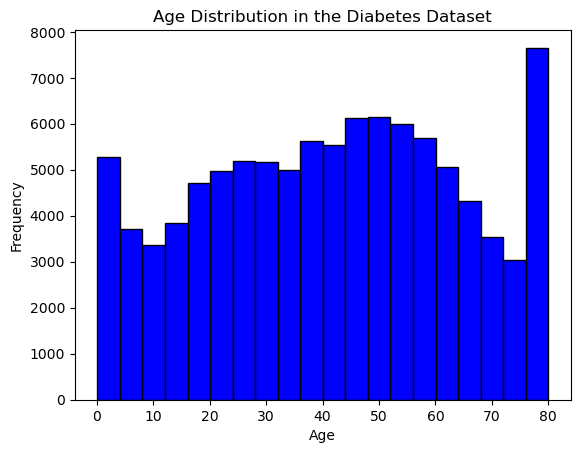

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.hist(df["age"],bins=20,color="blue",edgecolor="black")
plt.title("Age Distribution in the Diabetes Dataset")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

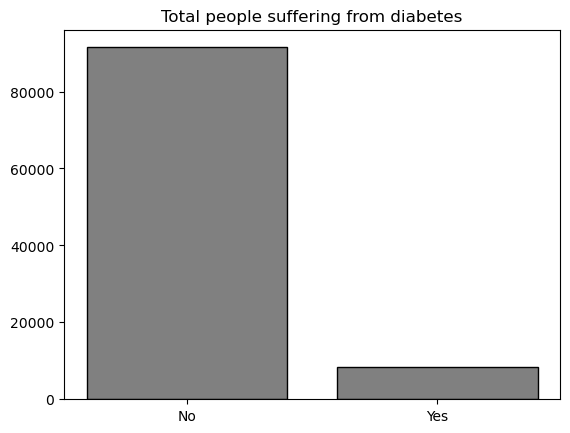

In [12]:
import matplotlib.pyplot as plt
c=df["diabetes"].value_counts()
plt.bar(c.index,c.values,color="grey",edgecolor="black")
plt.title("Total people suffering from diabetes")
plt.show()

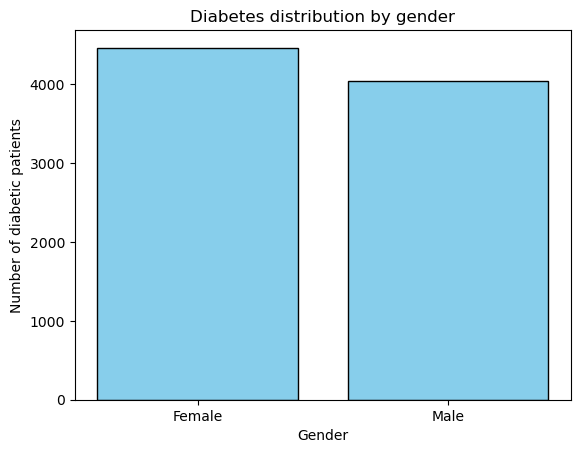

In [13]:
import matplotlib.pyplot as plt
count3=df[df["diabetes"] == "Yes"]["gender"].value_counts()
plt.bar(count3.index,count3.values,color="skyblue",edgecolor="black")
plt.xlabel("Gender")
plt.ylabel("Number of diabetic patients")
plt.title("Diabetes distribution by gender")
plt.show()

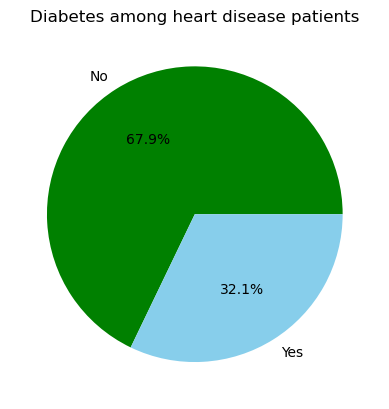

In [14]:
import matplotlib.pyplot as plt
count4=df[df["heart_disease"]=="Yes"]["diabetes"].value_counts()
plt.pie(count4.values,labels=count4.index,colors=["green","skyblue"],autopct="%1.1f%%")
plt.title("Diabetes among heart disease patients")
plt.show()

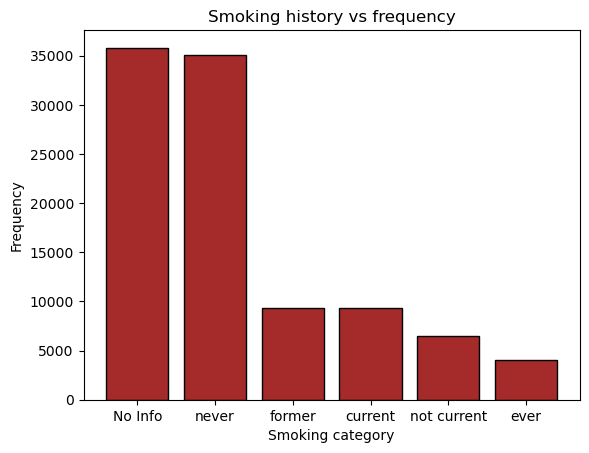

In [15]:
import matplotlib.pyplot as plt
count2=df["smoking_history"].value_counts()
plt.bar(count2.index,count2.values,color="brown",edgecolor="black")
plt.xlabel("Smoking category")
plt.ylabel("Frequency")
plt.title("Smoking history vs frequency")
plt.show()

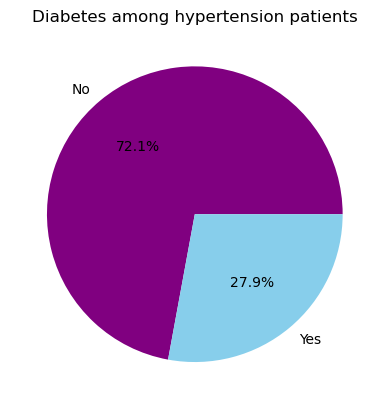

In [16]:
count5=df[df["hypertension"]=="Yes"]["diabetes"].value_counts()
plt.pie(count5.values,labels=count5.index,colors=["purple","skyblue"],autopct="%1.1f%%")
plt.title("Diabetes among hypertension patients")
plt.show()


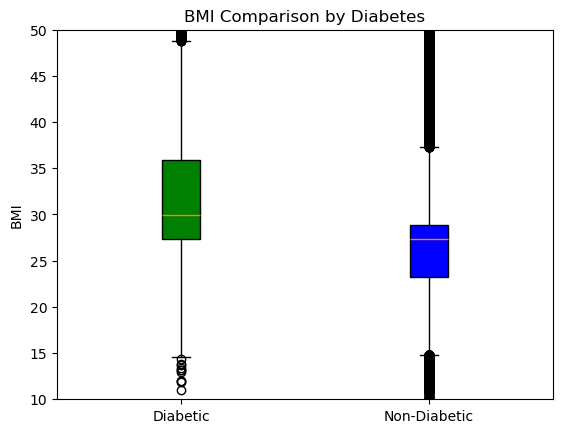

In [17]:
import matplotlib.pyplot as plt
diabetic=df[df["diabetes"]=="Yes"]["bmi"]
non_diabetic=df[df["diabetes"]=="No"]["bmi"]
import matplotlib.pyplot as plt
box = plt.boxplot([diabetic, non_diabetic],
                  tick_labels=["Diabetic", "Non-Diabetic"],
                  patch_artist=True) 
plt.ylim(10, 50)
plt.title("BMI Comparison by Diabetes")
plt.ylabel("BMI")
box['boxes'][0].set_facecolor('green')
box['boxes'][1].set_facecolor('blue')

plt.show()

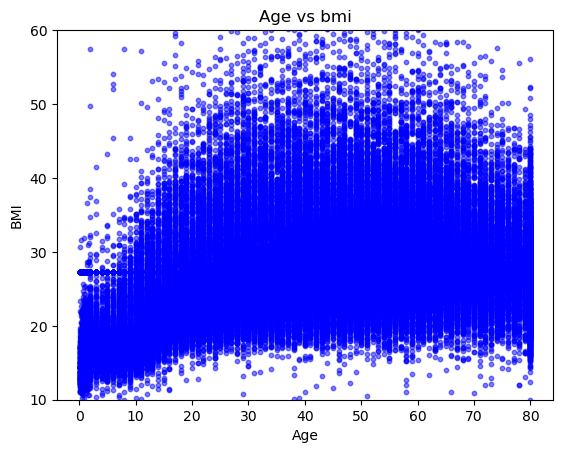

In [18]:
import matplotlib.pyplot as plt
plt.scatter(df["age"], df["bmi"], s=10, alpha=0.5,color="blue")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.ylim(10,60)
plt.title("Age vs bmi")
plt.show()

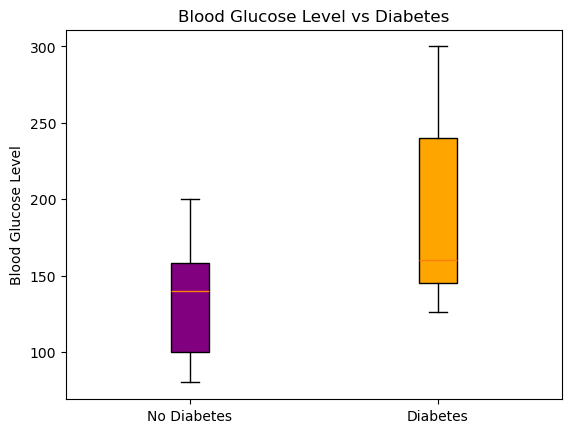

In [19]:
import matplotlib.pyplot as plt

box = plt.boxplot([df[df['diabetes']=="No"]['blood_glucose_level'],
                   df[df['diabetes']=="Yes"]['blood_glucose_level']],
                  tick_labels=['No Diabetes','Diabetes'],
                  patch_artist=True)

box['boxes'][0].set_facecolor('purple')
box['boxes'][1].set_facecolor('orange')

plt.title("Blood Glucose Level vs Diabetes")
plt.ylabel("Blood Glucose Level")

plt.show()

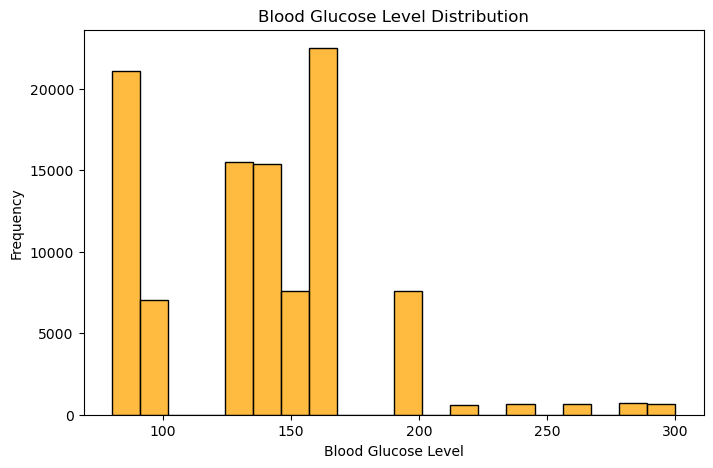

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='blood_glucose_level', bins=20, color='orange', edgecolor='black', kde=False)

plt.title("Blood Glucose Level Distribution")
plt.xlabel("Blood Glucose Level")
plt.ylabel("Frequency")
plt.show()

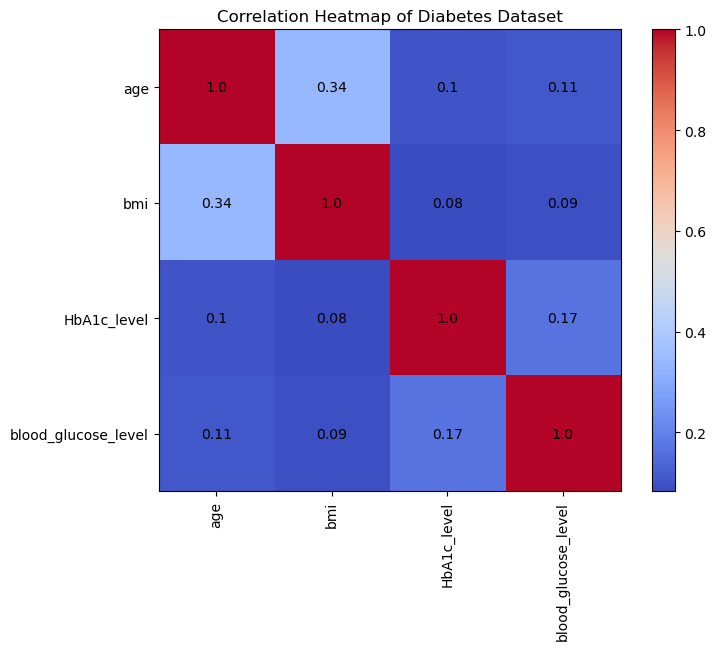

In [22]:
import matplotlib.pyplot as plt
import numpy as np

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add values inside boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center', color='black')

plt.title("Correlation Heatmap of Diabetes Dataset")

plt.show()